<a href="https://colab.research.google.com/github/HRI328/ML-Pipeline-Text-Embeddings-Logistic-Regression/blob/main/Logistic_Regression_with_and_without_text.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# pip install sentence-transformers

In [12]:
"""
ML Pipeline: Text Embeddings + Numerical/Categorical Features + Logistic Regression
Includes: PCA-based text embedding (10-dim), feature selection, hyperparameter optimisation,
          and WITH vs WITHOUT text message performance comparison.
"""

import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectFromModel, mutual_info_classif, SelectKBest
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, accuracy_score,
    f1_score, precision_score, recall_score,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.inspection import permutation_importance
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)


# =============================================================================
# DATASET CONFIGURATION
# Update these to match your own dataset's column names.
# NUM_COLS is set dynamically by generate_dataset via n_num_features.
# =============================================================================

NUM_COLS     = []                                                     # populated by generate_dataset
CAT_COLS     = ["cat_feature_A", "cat_feature_B"]                    # categorical features
TEXT_COL     = "text_message"                                         # text column
TARGET_COL   = "target"                                               # label column


# =============================================================================
# 1. GENERATE SYNTHETIC DATASET
# =============================================================================

def generate_dataset(
    n_samples:      int   = 1000,
    n_num_features: int   = 3,
    text_noise_pct: float = 0.0,   # 0.0 = no noise, 0.2 = 20% of messages corrupted
) -> pd.DataFrame:
    """
    Generates a synthetic dataset with:
      - n_num_features numerical features (default 3, can be 4, 5, 10, etc.)
      - 2 categorical features
      - 1 text message column
      - 1 binary target label

    text_noise_pct : float in [0, 1]
        Fraction of text messages to corrupt with random noise.
        Noise operations applied at random to each selected message:
          • word shuffle   — scrambles word order
          • word drop      — removes a random word
          • char swap      — swaps two adjacent characters in a random word
          • random insert  — inserts a random meaningless token
        E.g. text_noise_pct=0.2 corrupts ~20% of messages.

    Also updates the global NUM_COLS so all downstream functions
    (build_feature_matrix, feature selection, etc.) use the correct columns.
    """
    global NUM_COLS
    NUM_COLS = [f"num_feature_{i+1}" for i in range(n_num_features)]

    X_num, y = make_classification(
        n_samples=n_samples,
        n_features=n_num_features,
        n_informative=max(1, n_num_features - 1),
        n_redundant=min(1, n_num_features - 1),
        random_state=42
    )

    # Categorical features
    categories_A = np.random.choice(["low", "medium", "high"], size=n_samples)
    categories_B = np.random.choice(["cat", "dog", "bird", "fish"], size=n_samples)

    # Text messages (correlated with label for realism)
    positive_texts = [
        "excellent service and fast delivery",
        "great product, highly recommend",
        "amazing quality, very satisfied",
        "superb experience, will buy again",
        "fantastic item, exceeded expectations",
        "outstanding support and quick response",
        "brilliant product and smooth checkout",
        "quality is not good enough",
        "not sure",
    ]
    negative_texts = [
        "terrible service, very disappointed",
        "poor quality item, waste of money",
        "awful experience, would not recommend",
        "broken on arrival, very frustrated",
        "horrible support, no response",
        "defective product, extremely unhappy",
        "dreadful quality, major disappointment",
        "worth to suspect",
        "Just normal",
    ]

    # ── Noise helper ──────────────────────────────────────────────────────
    _junk_tokens = ["zzz", "xqr", "foo", "baz", "meh", "xyz", "blah"]

    def _add_text_noise(text: str) -> str:
        """Apply one random corruption to the text."""
        words = text.split()
        op = np.random.choice(["shuffle", "drop", "char_swap", "insert"])
        if op == "shuffle" and len(words) > 1:
            np.random.shuffle(words)
        elif op == "drop" and len(words) > 1:
            del words[np.random.randint(len(words))]
        elif op == "char_swap":
            idx = np.random.randint(len(words))
            w = list(words[idx])
            if len(w) > 1:
                i = np.random.randint(len(w) - 1)
                w[i], w[i + 1] = w[i + 1], w[i]
            words[idx] = "".join(w)
        elif op == "insert":
            pos = np.random.randint(len(words) + 1)
            words.insert(pos, np.random.choice(_junk_tokens))
        return " ".join(words)

    # ── Build text column ─────────────────────────────────────────────────
    texts = []
    for label in y:
        pool = positive_texts if label == 1 else negative_texts
        base = np.random.choice(pool)
        suffix = np.random.choice(["", " overall", " honestly", " truly"],
                                  p=[0.5, 0.2, 0.2, 0.1])
        texts.append(base + suffix)

    # Apply noise to a random text_noise_pct fraction of messages
    if text_noise_pct > 0:
        n_noisy = int(round(len(texts) * text_noise_pct))
        noisy_idx = np.random.choice(len(texts), size=n_noisy, replace=False)
        for i in noisy_idx:
            texts[i] = _add_text_noise(texts[i])
        print(f"  [generate_dataset] Text noise: {text_noise_pct:.0%} "
              f"({n_noisy}/{len(texts)} messages corrupted)")

    df = pd.DataFrame(X_num, columns=NUM_COLS)
    df[CAT_COLS[0]] = categories_A
    df[CAT_COLS[1]] = categories_B
    df[TEXT_COL]    = texts
    df[TARGET_COL]  = y
    return df


# =============================================================================
# 2. TEXT → 10-DIMENSION EMBEDDING  (Pretrained Sentence Transformer + PCA)
# =============================================================================
#
#  WHY PRETRAINED IS THE RIGHT CHOICE
#  ───────────────────────────────────
#  A pretrained model was trained on billions of sentences.  Every word it has
#  ever seen (including synonyms, typos, domain terms) already has a rich,
#  semantically meaningful representation.  We just borrow those weights.
#
#  FIT / TRANSFORM CONTRACT (no leakage)
#  ──────────────────────────────────────
#  The SentenceTransformer weights are COMPLETELY FROZEN — they never update.
#  The only thing fitted on training data is the PCA projection (384 → 10).
#  Test data goes through the same frozen model + frozen PCA, so train and
#  test embeddings always live in the same 10-dimensional space.
#
#  SETUP (run once in your environment)
#  ──────────────────────────────────────
#    pip install sentence-transformers
#
#  MODEL OPTIONS (swap via model_name parameter)
#  ──────────────────────────────────────────────
#    "all-MiniLM-L6-v2"        22M params, 384-dim, fastest, great quality  ← default
#    "all-mpnet-base-v2"        110M params, 768-dim, best quality, slower
#    "paraphrase-MiniLM-L3-v2"  17M params, 384-dim, ultra-fast, good quality
#    "all-distilroberta-v1"     82M params, 768-dim, strong on short texts
#
# =============================================================================

try:
    from sentence_transformers import SentenceTransformer as _ST
    _SENTENCE_TRANSFORMERS_AVAILABLE = True
except ImportError:
    _SENTENCE_TRANSFORMERS_AVAILABLE = False


class TextEmbedder:
    """
    Pretrained Sentence Transformer embedder with PCA compression.

    fit_transform(train_texts)
    ──────────────────────────
      1. Load frozen pretrained model (e.g. all-MiniLM-L6-v2, 384-dim)
      2. Encode all training sentences  →  (N_train, 384)
      3. Fit PCA on training embeddings →  learn 384→out_dim projection
      4. Return compressed embeddings   →  (N_train, out_dim)

    transform(texts)   ← call on train OR test
    ──────────────────
      1. Encode with the same frozen model   →  (N, 384)
      2. Apply frozen PCA                    →  (N, out_dim)
      ✓ Train and test always share the same embedding space

    Parameters
    ----------
    out_dim      : final embedding size after PCA (default 10)
    model_name   : HuggingFace model ID (default "all-MiniLM-L6-v2")
    batch_size   : encoding batch size (default 64)
    seed         : PCA random state
    """

    def __init__(
        self,
        out_dim:    int = 10,
        model_name: str = "all-MiniLM-L6-v2",
        batch_size: int = 64,
        seed:       int = 42,
    ):
        if not _SENTENCE_TRANSFORMERS_AVAILABLE:
            raise ImportError(
                "\n\n  sentence-transformers is not installed.\n"
                "  Run:  pip install sentence-transformers\n"
                "  then re-run this script.\n"
            )
        self.out_dim     = out_dim
        self.model_name  = model_name
        self.batch_size  = batch_size
        self.seed        = seed
        self.col_names   = [f"text_emb_{i+1}" for i in range(out_dim)]

        # Loaded / fitted at runtime — never touches test data
        self._model: _ST       = None   # frozen pretrained weights
        self._pca:   PCA       = None   # fitted on training embeddings only
        self._native_dim: int  = None   # raw model output dimensionality

    # ── Internal helpers ──────────────────────────────────────────────────

    def _load_model(self) -> None:
        if self._model is None:
            print(f"  [TextEmbedder] Loading pretrained model: {self.model_name} ...")
            self._model = _ST(self.model_name)
            # Probe native output dimensionality
            probe = self._model.encode(["probe"], show_progress_bar=False)
            self._native_dim = probe.shape[1]
            print(f"  [TextEmbedder] Native embedding dim : {self._native_dim}")

    def _encode(self, texts: pd.Series) -> np.ndarray:
        """Encode texts with the frozen pretrained model → (N, native_dim)."""
        return self._model.encode(
            texts.tolist(),
            batch_size=self.batch_size,
            show_progress_bar=False,
            convert_to_numpy=True,
        )

    # ── Public API ────────────────────────────────────────────────────────

    def fit_transform(self, texts: pd.Series) -> pd.DataFrame:
        """
        Encode training texts with frozen pretrained model,
        then fit PCA on those embeddings.
        Must be called on TRAINING data only.
        """
        self._load_model()

        print(f"  [TextEmbedder] Encoding {len(texts)} training sentences ...")
        train_vecs = self._encode(texts)                  # frozen model, no fit

        print(f"  [TextEmbedder] Fitting PCA {self._native_dim}→{self.out_dim} "
              f"on training embeddings ...")
        self._pca = PCA(n_components=self.out_dim, random_state=self.seed)
        reduced   = self._pca.fit_transform(train_vecs)  # PCA fit on train only
        explained = self._pca.explained_variance_ratio_.sum()

        print(f"  [TextEmbedder] PCA explained variance : {explained:.2%}")
        print(f"  [TextEmbedder] ✓ PCA FROZEN — same projection applied to test data")
        return pd.DataFrame(reduced, columns=self.col_names, index=texts.index)

    def transform(self, texts: pd.Series) -> pd.DataFrame:
        """
        Encode any texts (train or test) using:
          • frozen pretrained model weights (never updated)
          • frozen PCA fitted only on training embeddings
        Train and test are guaranteed to share the same embedding space.
        """
        assert self._model is not None, "Call fit_transform on training data first."
        assert self._pca   is not None, "Call fit_transform on training data first."

        vecs    = self._encode(texts)          # same frozen model
        reduced = self._pca.transform(vecs)    # same frozen PCA
        return pd.DataFrame(reduced, columns=self.col_names, index=texts.index)


# =============================================================================
# 3. FULL PREPROCESSING PIPELINE
# =============================================================================

def build_feature_matrix(
    df: pd.DataFrame,
    text_embedder: TextEmbedder,
    fit: bool = True,
    ohe: OneHotEncoder = None,
    scaler: StandardScaler = None,
    num_cols: list[str] = None,
    cat_cols: list[str] = None,
    text_col: str = None,
) -> tuple[pd.DataFrame, OneHotEncoder, StandardScaler]:
    """
    Combines:
      - Scaled numerical features  (defaults to global NUM_COLS)
      - One-hot encoded categorical features  (defaults to global CAT_COLS)
      - Pretrained text embeddings  (defaults to global TEXT_COL)

    Pass num_cols / cat_cols / text_col explicitly to override the globals.
    """
    num_cols  = num_cols  if num_cols  is not None else NUM_COLS
    cat_cols  = cat_cols  if cat_cols  is not None else CAT_COLS
    text_col  = text_col  if text_col  is not None else TEXT_COL

    # ---- Numerical ----
    if fit:
        scaler = StandardScaler()
        num_scaled = scaler.fit_transform(df[num_cols])
    else:
        num_scaled = scaler.transform(df[num_cols])
    num_df = pd.DataFrame(num_scaled, columns=num_cols, index=df.index)

    # ---- Categorical ----
    if fit:
        ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
        cat_encoded = ohe.fit_transform(df[cat_cols])
    else:
        cat_encoded = ohe.transform(df[cat_cols])
    cat_df = pd.DataFrame(
        cat_encoded,
        columns=ohe.get_feature_names_out(cat_cols),
        index=df.index,
    )

    # ---- Text ----
    if fit:
        text_df = text_embedder.fit_transform(df[text_col])
    else:
        text_df = text_embedder.transform(df[text_col])

    return pd.concat([num_df, cat_df, text_df], axis=1), ohe, scaler


# =============================================================================
# 4. FEATURE SELECTION  (embedding-aware)
# =============================================================================

def select_features(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    k: int = 15,
    emb_prefix: str = "text_emb_",
) -> tuple[np.ndarray, list[str], pd.Series]:
    """
    Mutual-information feature selection that treats text embedding dimensions
    as an atomic group — all embedding columns are kept or dropped together.

    Why this matters
    ────────────────
    The 10 text_emb_* columns are not independent features: they are the
    coordinates of a single point in a 10-dimensional semantic space learned
    by the pretrained model.  Selecting some dimensions and discarding others
    destroys that geometry — e.g. keeping dims 1-3 and dropping 4-10 is like
    keeping only the X-axis of a 3-D point.  The embedding must be treated as
    one unit.

    Algorithm
    ─────────
    1. Identify embedding columns (prefix "text_emb_") and non-embedding cols.
    2. Score every non-embedding column individually with mutual information.
    3. Score the embedding GROUP as a whole: compute mean MI across all dims.
    4. Build a single ranked list:
         • non-embedding features ranked by individual MI score
         • embedding group represented by its mean score (kept or dropped as one)
    5. Select top-k "slots".  If the embedding group ranks within top-k, ALL
       embedding dims are included (they count as one slot).
    6. Return the boolean mask, selected feature names, and the full score series.
    """
    emb_cols  = [c for c in X_train.columns if c.startswith(emb_prefix)]
    other_cols = [c for c in X_train.columns if not c.startswith(emb_prefix)]

    # ── Score non-embedding features individually ─────────────────────────
    mi_other = mutual_info_classif(X_train[other_cols], y_train, random_state=42)
    other_scores = pd.Series(mi_other, index=other_cols)

    # ── Score embedding group as a whole (mean MI across all dims) ────────
    if emb_cols:
        mi_emb = mutual_info_classif(X_train[emb_cols], y_train, random_state=42)
        emb_group_score = float(np.mean(mi_emb))
        emb_dim_scores  = pd.Series(mi_emb, index=emb_cols)
    else:
        emb_group_score = -1.0          # no embeddings → never selected
        emb_dim_scores  = pd.Series(dtype=float)

    # ── Build unified score series for display ────────────────────────────
    # Show each embedding dim at its individual score, but selection is binary
    all_scores = pd.concat([other_scores, emb_dim_scores]).sort_values(ascending=False)

    # ── Rank: non-emb features + embedding group as one entry ────────────
    # Create a ranking list of (name, score) where embedding is one entry
    ranking = list(other_scores.sort_values(ascending=False).items())
    if emb_cols:
        # Insert the group at the position its score falls in
        inserted = False
        for i, (_, s) in enumerate(ranking):
            if emb_group_score >= s and not inserted:
                ranking.insert(i, ("__emb_group__", emb_group_score))
                inserted = True
                break
        if not inserted:
            ranking.append(("__emb_group__", emb_group_score))

    # ── Select top-k slots ────────────────────────────────────────────────
    selected_names: list[str] = []
    emb_included = False
    for name, _ in ranking[:k]:
        if name == "__emb_group__":
            selected_names.extend(emb_cols)   # include ALL embedding dims
            emb_included = True
        else:
            selected_names.append(name)

    mask = X_train.columns.isin(selected_names)

    # ── Report ────────────────────────────────────────────────────────────
    n_total_logical = len(other_cols) + (1 if emb_cols else 0)
    print(f"\n  [FeatureSelection] Logical features  : {n_total_logical} "
          f"({len(other_cols)} individual + {'1 embedding group' if emb_cols else 'no embedding'})")
    print(f"  [FeatureSelection] Top-{k} slots selected")
    if emb_cols:
        print(f"  [FeatureSelection] Embedding group score (mean MI) : {emb_group_score:.4f} "
              f"→ {'INCLUDED ✓' if emb_included else 'EXCLUDED ✗'}")
    print(f"  [FeatureSelection] Selected ({sum(mask)} columns): {selected_names}\n")

    return mask, selected_names, all_scores


# =============================================================================
# 5. MODEL OPTIMISATION  (GridSearchCV)
# =============================================================================

def optimise_model(
    X_train: np.ndarray,
    y_train: np.ndarray,
) -> tuple[LogisticRegression, dict]:
    """
    Grid-searches over Logistic Regression hyperparameters using
    5-fold stratified cross-validation.
    """
    param_grid = [
        # L2 (Ridge) penalty
        {"C": [0.001, 0.01, 0.1], "penalty": ["l2"], "solver": ["lbfgs"]},
        # L1 (Lasso) penalty
        {"C": [0.001, 0.01, 0.1], "penalty": ["l1"], "solver": ["liblinear"]},
        # ElasticNet
        {"C": [0.001, 0.01, 0.1], "penalty": ["elasticnet"],
         "solver": ["saga"], "l1_ratio": [0.3, 0.5, 0.7]},
    ]

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    grid = GridSearchCV(
        LogisticRegression(max_iter=2000, random_state=42),
        param_grid,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1,
        verbose=0,
        return_train_score=True,
    )
    grid.fit(X_train, y_train)

    print(f"  [GridSearch] Best params : {grid.best_params_}")
    print(f"  [GridSearch] Best CV AUC : {grid.best_score_:.4f}")
    return grid.best_estimator_, grid.best_params_, grid.cv_results_


# =============================================================================
# 6. EVALUATION & PLOTS
# =============================================================================

def evaluate_model(model, X_test, y_test, feature_names):
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    auc     = roc_auc_score(y_test, y_proba)

    print("\n" + "="*60)
    print("MODEL EVALUATION ON TEST SET")
    print("="*60)
    print(classification_report(y_test, y_pred, target_names=["Class 0", "Class 1"]))
    print(f"  ROC-AUC : {auc:.4f}")
    return y_pred, y_proba, auc


def plot_results(
    model, X_test, y_test, y_pred, y_proba,
    feature_names, mi_scores, cv_results,
):
    fig = plt.figure(figsize=(20, 14))
    fig.suptitle("ML Pipeline — Results Dashboard", fontsize=16, fontweight="bold", y=0.98)
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

    # ── (A) Mutual Information scores ──────────────────────────────────────
    ax0 = fig.add_subplot(gs[0, 0])
    top_mi = mi_scores.head(20).sort_values()
    colors = ["#E74C3C" if n in feature_names else "#3498DB" for n in top_mi.index]
    top_mi.plot(kind="barh", ax=ax0, color=colors)
    ax0.set_title("Feature MI Scores\n(red = selected)", fontsize=11)
    ax0.set_xlabel("Mutual Information")
    ax0.tick_params(labelsize=8)

    # ── (B) Confusion Matrix ───────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 1])
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                           display_labels=["Class 0", "Class 1"]).plot(ax=ax1, colorbar=False)
    ax1.set_title("Confusion Matrix", fontsize=11)

    # ── (C) ROC Curve ──────────────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 2])
    RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax2, color="#E74C3C")
    ax2.plot([0, 1], [0, 1], "k--", lw=1)
    ax2.set_title("ROC Curve", fontsize=11)

    # ── (D) CV AUC distribution (best 30 param combos) ────────────────────
    ax3 = fig.add_subplot(gs[1, 0])
    cv_df = pd.DataFrame(cv_results)
    cv_df = cv_df.sort_values("mean_test_score", ascending=False).head(30)
    ax3.barh(range(len(cv_df)), cv_df["mean_test_score"],
             xerr=cv_df["std_test_score"], color="#2ECC71", ecolor="gray", capsize=3)
    ax3.axvline(cv_df["mean_test_score"].iloc[0], color="red", linestyle="--", lw=1.5, label="Best")
    ax3.set_title("GridSearch: CV AUC (top-30 combos)", fontsize=11)
    ax3.set_xlabel("Mean Test AUC")
    ax3.legend(fontsize=8)
    ax3.invert_yaxis()

    # ── (E) Logistic Regression Coefficients ──────────────────────────────
    ax4 = fig.add_subplot(gs[1, 1])
    coef_series = pd.Series(model.coef_[0], index=feature_names).sort_values()
    coef_colors = ["#E74C3C" if v > 0 else "#3498DB" for v in coef_series]
    coef_series.plot(kind="barh", ax=ax4, color=coef_colors)
    ax4.axvline(0, color="black", lw=0.8)
    ax4.set_title("LR Coefficients\n(red=pos / blue=neg)", fontsize=11)
    ax4.tick_params(labelsize=8)

    # ── (F) Text Embedding variance explained ─────────────────────────────
    ax5 = fig.add_subplot(gs[1, 2])
    # Rebuild embedder reference — we'll extract from the saved object
    ax5.set_title("Pipeline Architecture", fontsize=11)
    pipeline_text = (
        "Text Message\n"
        "     ↓\n"
        "Pretrained Sentence Transformer\n"
        "  all-MiniLM-L6-v2 (22M params)\n"
        "  Trained on 1B+ sentences\n"
        "  Weights COMPLETELY FROZEN\n"
        "     ↓\n"
        "384-dim sentence embedding\n"
        "(handles OOV, synonyms,\n"
        " context, semantics)\n"
        "     ↓\n"
        "PCA 384 → 10 dims\n"
        "  [fit on train only, frozen]\n"
        "     ↓\n"
        "Concat: Numeric + Categorical\n"
        "     ↓\n"
        "Mutual Info Feature Selection\n"
        "     ↓\n"
        "Logistic Regression\n"
        "(GridSearchCV optimised)"
    )
    ax5.text(0.5, 0.5, pipeline_text, transform=ax5.transAxes,
             ha="center", va="center", fontsize=9.5,
             bbox=dict(boxstyle="round,pad=0.6", facecolor="#F0F3F4", edgecolor="#BDC3C7"),
             fontfamily="monospace")
    ax5.axis("off")

    # plt.savefig("ml_pipeline_results.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    print("\n  [Plot] Saved → ml_pipeline_results.png")


# =============================================================================
# 7. WITH vs WITHOUT TEXT — COMPARISON
# =============================================================================

def run_variant(
    train_df:   pd.DataFrame,
    test_df:    pd.DataFrame,
    y_train:    pd.Series,
    y_test:     pd.Series,
    use_text:   bool,
    k_features: int = 15,
    cv_folds:   int = 5,
) -> dict:
    """
    Builds a fully independent pipeline for one variant:
      - WITH text  : num + cat + text embeddings → feature selection → LR
      - WITHOUT text: num + cat only             → feature selection → LR

    Each variant:
      • Constructs its own feature matrix from scratch (train & test)
      • Runs its own feature selection fitted on training data only
      • Runs its own GridSearchCV hyperparameter optimisation
      • Is evaluated on the test set built with the same features

    No artifacts are shared between variants — the comparison is fully objective.
    """
    label = "WITH text" if use_text else "WITHOUT text"
    print(f"\n  ── Variant: {label} ──")

    # ── Build feature matrices ────────────────────────────────────────────
    embedder = TextEmbedder(out_dim=10)
    X_train_full, ohe, scaler = build_feature_matrix(
        train_df, embedder, fit=True
    )
    X_test_full, _, _ = build_feature_matrix(
        test_df, embedder, fit=False, ohe=ohe, scaler=scaler
    )

    # Drop text columns for the WITHOUT-text variant
    if not use_text:
        text_cols    = [c for c in X_train_full.columns if c.startswith("text_emb_")]
        X_train_full = X_train_full.drop(columns=text_cols)
        X_test_full  = X_test_full.drop(columns=text_cols)

    print(f"    Feature set : {X_train_full.shape[1]} features — "
          f"{list(X_train_full.columns)}")

    # ── Feature selection (fitted on training data only) ──────────────────
    k = min(k_features, X_train_full.shape[1])
    selector    = SelectKBest(score_func=mutual_info_classif, k=k)
    X_train_sel = selector.fit_transform(X_train_full, y_train)
    X_test_sel  = selector.transform(X_test_full)      # ← same test features
    sel_names   = list(X_train_full.columns[selector.get_support()])

    # ── Hyperparameter optimisation ───────────────────────────────────────
    best_model, best_params, _ = optimise_model(X_train_sel, y_train.values)

    # ── Hold-out evaluation on the corresponding test set ─────────────────
    y_pred  = best_model.predict(X_test_sel)
    y_proba = best_model.predict_proba(X_test_sel)[:, 1]

    # ── Cross-validated scores (training set only) ────────────────────────
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    cv_res = cross_validate(
        best_model, X_train_sel, y_train.values,
        cv=cv, scoring=["roc_auc", "accuracy", "f1"],
        return_train_score=False,
    )

    metrics = {
        "label":       label,
        "n_features":  X_train_sel.shape[1],
        "selected":    sel_names,
        "best_params": best_params,
        # Hold-out metrics
        "accuracy":    accuracy_score(y_test, y_pred),
        "precision":   precision_score(y_test, y_pred),
        "recall":      recall_score(y_test, y_pred),
        "f1":          f1_score(y_test, y_pred),
        "auc":         roc_auc_score(y_test, y_proba),
        "y_pred":      y_pred,
        "y_proba":     y_proba,
        # Cross-val distributions
        "cv_auc":      cv_res["test_roc_auc"],
        "cv_accuracy": cv_res["test_accuracy"],
        "cv_f1":       cv_res["test_f1"],
        "cv_auc_mean": cv_res["test_roc_auc"].mean(),
        "cv_auc_std":  cv_res["test_roc_auc"].std(),
        "cv_f1_mean":  cv_res["test_f1"].mean(),
        "cv_f1_std":   cv_res["test_f1"].std(),
        "model":       best_model,
        "X_test_sel":  X_test_sel,
    }

    print(f"    Selected features : {sel_names}")
    print(f"    Best params       : {best_params}")
    print(f"    Hold-out AUC      : {metrics['auc']:.4f}")
    print(f"    Hold-out F1       : {metrics['f1']:.4f}")
    print(f"    CV AUC            : {metrics['cv_auc_mean']:.4f} ± {metrics['cv_auc_std']:.4f}")
    return metrics


def significance_test(cv_scores_a: np.ndarray, cv_scores_b: np.ndarray) -> dict:
    """Paired t-test between two sets of CV fold scores."""
    t_stat, p_val = stats.ttest_rel(cv_scores_a, cv_scores_b)
    significant = p_val < 0.05
    direction   = "higher" if cv_scores_a.mean() > cv_scores_b.mean() else "lower"
    conclusion  = (
        f"Statistically significant (p={p_val:.4f}): WITH text is {direction}."
        if significant
        else f"Not statistically significant (p={p_val:.4f}): difference may be due to chance."
    )
    return {"t_stat": t_stat, "p_val": p_val, "significant": significant, "conclusion": conclusion}


def compare_with_without_text(
    train_df: pd.DataFrame,
    test_df:  pd.DataFrame,
    y_train:  pd.Series,
    y_test:   pd.Series,
    k_features: int = 15,
) -> tuple[dict, dict]:
    """
    Objective comparison of two fully independent models:

      Model A — WITH text
        • Train features : num + cat + 10-dim text embeddings
        • Test features  : same (embedder frozen on train)
        • Own feature selection, own GridSearchCV

      Model B — WITHOUT text
        • Train features : num + cat only
        • Test features  : same
        • Own feature selection, own GridSearchCV

    Both models see the same rows (same train/test split) but live in
    different feature spaces.  Neither shares any artifact with the other
    or with the main pipeline model.
    """
    print("\n" + "=" * 60)
    print("COMPARISON: WITH vs WITHOUT Text Embeddings")
    print("=" * 60)
    print("  Each variant is built from scratch with its own feature set,")
    print("  feature selection, and hyperparameter search.\n")

    with_text    = run_variant(train_df, test_df, y_train, y_test, use_text=True, k_features=k_features)
    without_text = run_variant(train_df, test_df, y_train, y_test, use_text=False, k_features=k_features)

    # ── Statistical significance (paired t-test on CV AUC folds) ─────────
    sig = significance_test(with_text["cv_auc"], without_text["cv_auc"])

    # ── Console summary table ─────────────────────────────────────────────
    metrics_to_show = ["accuracy", "precision", "recall", "f1", "auc",
                       "cv_auc_mean", "cv_f1_mean"]
    col_w = 14
    header = (f"{'Metric':<18}"
              f"{'WITH text':>{col_w}}"
              f"{'WITHOUT text':>{col_w}}"
              f"{'Δ (with−without)':>{col_w+4}}")
    print("\n" + "─" * len(header))
    print(header)
    print("─" * len(header))
    for m in metrics_to_show:
        w     = with_text[m]
        wo    = without_text[m]
        delta = w - wo
        arrow = "▲" if delta > 0 else ("▼" if delta < 0 else "─")
        print(f"  {m:<16}{w:>{col_w}.4f}{wo:>{col_w}.4f}   {arrow} {abs(delta):.4f}")
    print("─" * len(header))
    print(f"\n  Paired t-test on CV AUC: {sig['conclusion']}")
    print(f"  WITH text    best params : {with_text['best_params']}")
    print(f"  WITHOUT text best params : {without_text['best_params']}")

    _plot_comparison(with_text, without_text, y_test, sig)
    return with_text, without_text


def _plot_comparison(with_r: dict, without_r: dict, y_test: pd.Series, sig: dict):
    """Draws a 6-panel comparison dashboard."""
    COLORS = {"WITH text": "#2ECC71", "WITHOUT text": "#E74C3C"}
    fig = plt.figure(figsize=(20, 14))
    fig.suptitle(
        "Performance Comparison: WITH vs WITHOUT Text Message Embeddings",
        fontsize=15, fontweight="bold", y=0.98,
    )
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

    results   = [with_r, without_r]
    labels    = [r["label"] for r in results]
    bar_colors = [COLORS[l] for l in labels]

    # ── (A) Hold-out metric bar chart ──────────────────────────────────────
    ax0 = fig.add_subplot(gs[0, 0])
    metric_keys   = ["accuracy", "precision", "recall", "f1", "auc"]
    metric_labels = ["Accuracy", "Precision", "Recall", "F1", "AUC"]
    x  = np.arange(len(metric_keys))
    bw = 0.35
    for i, (res, color) in enumerate(zip(results, bar_colors)):
        vals = [res[m] for m in metric_keys]
        bars = ax0.bar(x + i * bw, vals, bw, label=res["label"], color=color, alpha=0.85)
        for bar, val in zip(bars, vals):
            ax0.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                     f"{val:.3f}", ha="center", va="bottom", fontsize=7.5)
    ax0.set_xticks(x + bw / 2)
    ax0.set_xticklabels(metric_labels, fontsize=9)
    ax0.set_ylim(0, 1.12)
    ax0.set_title("Hold-Out Metrics", fontsize=11)
    ax0.legend(fontsize=8)
    ax0.set_ylabel("Score")

    # ── (B) CV AUC box plot ────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 1])
    bp = ax1.boxplot(
        [with_r["cv_auc"], without_r["cv_auc"]],
        labels=["WITH\ntext", "WITHOUT\ntext"],
        patch_artist=True,
        medianprops=dict(color="black", linewidth=2),
        widths=0.45,
    )
    for patch, color in zip(bp["boxes"], bar_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    # Overlay individual fold points
    for i, (scores, color) in enumerate(zip([with_r["cv_auc"], without_r["cv_auc"]], bar_colors), 1):
        ax1.scatter(np.full(len(scores), i) + np.random.uniform(-0.08, 0.08, len(scores)),
                    scores, color=color, edgecolors="black", zorder=3, s=40)
    p_str = f"p = {sig['p_val']:.4f}" + (" ✓ sig." if sig["significant"] else " (n.s.)")
    ax1.set_title(f"CV AUC Distribution\n({p_str})", fontsize=11)
    ax1.set_ylabel("AUC")
    ax1.set_ylim(max(0, min(with_r["cv_auc"].min(), without_r["cv_auc"].min()) - 0.05), 1.05)

    # ── (C) ROC curves overlaid ────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 2])
    for res, color in zip(results, bar_colors):
        RocCurveDisplay.from_predictions(
            y_test, res["y_proba"], ax=ax2,
            name=f"{res['label']} (AUC={res['auc']:.3f})",
            color=color,
        )
    ax2.plot([0, 1], [0, 1], "k--", lw=1)
    ax2.set_title("ROC Curves", fontsize=11)
    ax2.legend(fontsize=8, loc="lower right")

    # ── (D) Delta radar / grouped metric improvement ───────────────────────
    ax3 = fig.add_subplot(gs[1, 0])
    delta_keys   = ["accuracy", "precision", "recall", "f1", "auc", "cv_auc_mean", "cv_f1_mean"]
    delta_labels = ["Accuracy", "Precision", "Recall", "F1", "AUC", "CV AUC", "CV F1"]
    deltas = [with_r[m] - without_r[m] for m in delta_keys]
    d_colors = ["#2ECC71" if d >= 0 else "#E74C3C" for d in deltas]
    bars = ax3.barh(delta_labels, deltas, color=d_colors, alpha=0.85)
    ax3.axvline(0, color="black", lw=1.2)
    for bar, d in zip(bars, deltas):
        xpos = bar.get_width() + (0.001 if d >= 0 else -0.001)
        ha = "left" if d >= 0 else "right"
        ax3.text(xpos, bar.get_y() + bar.get_height() / 2,
                 f"{d:+.4f}", va="center", ha=ha, fontsize=8)
    ax3.set_title("Δ Score (WITH − WITHOUT text)\nGreen = text helps", fontsize=11)
    ax3.set_xlabel("Difference")

    # ── (E) Confusion matrices side-by-side ───────────────────────────────
    ax4l = fig.add_subplot(gs[1, 1])
    ax4r = fig.add_subplot(gs[1, 2])
    for ax, res, color in zip([ax4l, ax4r], results, bar_colors):
        cm = confusion_matrix(y_test, res["y_pred"])
        disp = ConfusionMatrixDisplay(cm, display_labels=["Class 0", "Class 1"])
        disp.plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(f"Confusion Matrix\n{res['label']}", fontsize=10)
        # Tint the title box
        ax.title.set_backgroundcolor(color + "44")   # hex alpha

    # ── Summary text box ──────────────────────────────────────────────────
    winner = "WITH text" if with_r["auc"] >= without_r["auc"] else "WITHOUT text"
    auc_gain = with_r["auc"] - without_r["auc"]
    summary = (
        f"{'='*38}\n"
        f"  SUMMARY\n"
        f"{'='*38}\n"
        f"  Winner (AUC) : {winner}\n"
        f"  AUC gain     : {auc_gain:+.4f}\n"
        f"  CV AUC gain  : {with_r['cv_auc_mean']-without_r['cv_auc_mean']:+.4f}\n"
        f"  Significance : {'Yes ✓' if sig['significant'] else 'No ✗'}\n"
        f"  p-value      : {sig['p_val']:.4f}\n"
        f"{'='*38}"
    )
    fig.text(
        0.5, 0.005, summary,
        ha="center", va="bottom", fontsize=9,
        fontfamily="monospace",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="#FDFEFE", edgecolor="#BDC3C7"),
    )

    # plt.savefig("comparison_results.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    print("\n  [Plot] Saved → comparison_results.png")

In [17]:
print("=" * 60)
print("STEP 1 — Generate Dataset")
print("=" * 60)

df = generate_dataset(n_samples=1000, n_num_features=3, text_noise_pct=0.2)  # 10% noisy messages
print(df.head(3).to_string())
print(f"\n  Shape: {df.shape} | Target distribution: {df['target'].value_counts().to_dict()}")

# ── Train / Test split ─────────────────────────────────────────────────
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df[TARGET_COL], random_state=42)
y_train = train_df[TARGET_COL].reset_index(drop=True)
y_test  = test_df[TARGET_COL].reset_index(drop=True)

STEP 1 — Generate Dataset
  [generate_dataset] Text noise: 20% (200/1000 messages corrupted)
   num_feature_1  num_feature_2  num_feature_3 cat_feature_A cat_feature_B                                      text_message  target
0       2.485478       2.399636      -1.465269          high          bird            outstanding support and quick response       1
1       2.204040      -1.069657       0.009795          high          fish  dreadful quality, major disappointment truly zzz       0
2      -0.572653      -0.754948       0.420330           low          fish    awful experience, would not recommend honestly       0

  Shape: (1000, 7) | Target distribution: {1: 501, 0: 499}



STEP 2 — Build Feature Matrix (Text → 10-dim Embedding)
  [TextEmbedder] Loading pretrained model: all-MiniLM-L6-v2 ...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [TextEmbedder] Native embedding dim : 384
  [TextEmbedder] Encoding 800 training sentences ...
  [TextEmbedder] Fitting PCA 384→10 on training embeddings ...
  [TextEmbedder] PCA explained variance : 72.72%
  [TextEmbedder] ✓ PCA FROZEN — same projection applied to test data

  Full feature matrix: 20 features
  Columns: ['num_feature_1', 'num_feature_2', 'num_feature_3', 'cat_feature_A_high', 'cat_feature_A_low', 'cat_feature_A_medium', 'cat_feature_B_bird', 'cat_feature_B_cat', 'cat_feature_B_dog', 'cat_feature_B_fish', 'text_emb_1', 'text_emb_2', 'text_emb_3', 'text_emb_4', 'text_emb_5', 'text_emb_6', 'text_emb_7', 'text_emb_8', 'text_emb_9', 'text_emb_10']

STEP 3 — Feature Selection (Mutual Information, top-k)
Number of Features Selected : 8

  [FeatureSelection] Logical features  : 11 (10 individual + 1 embedding group)
  [FeatureSelection] Top-8 slots selected
  [FeatureSelection] Embedding group score (mean MI) : 0.5489 → INCLUDED ✓
  [FeatureSelection] Selected (17 columns):

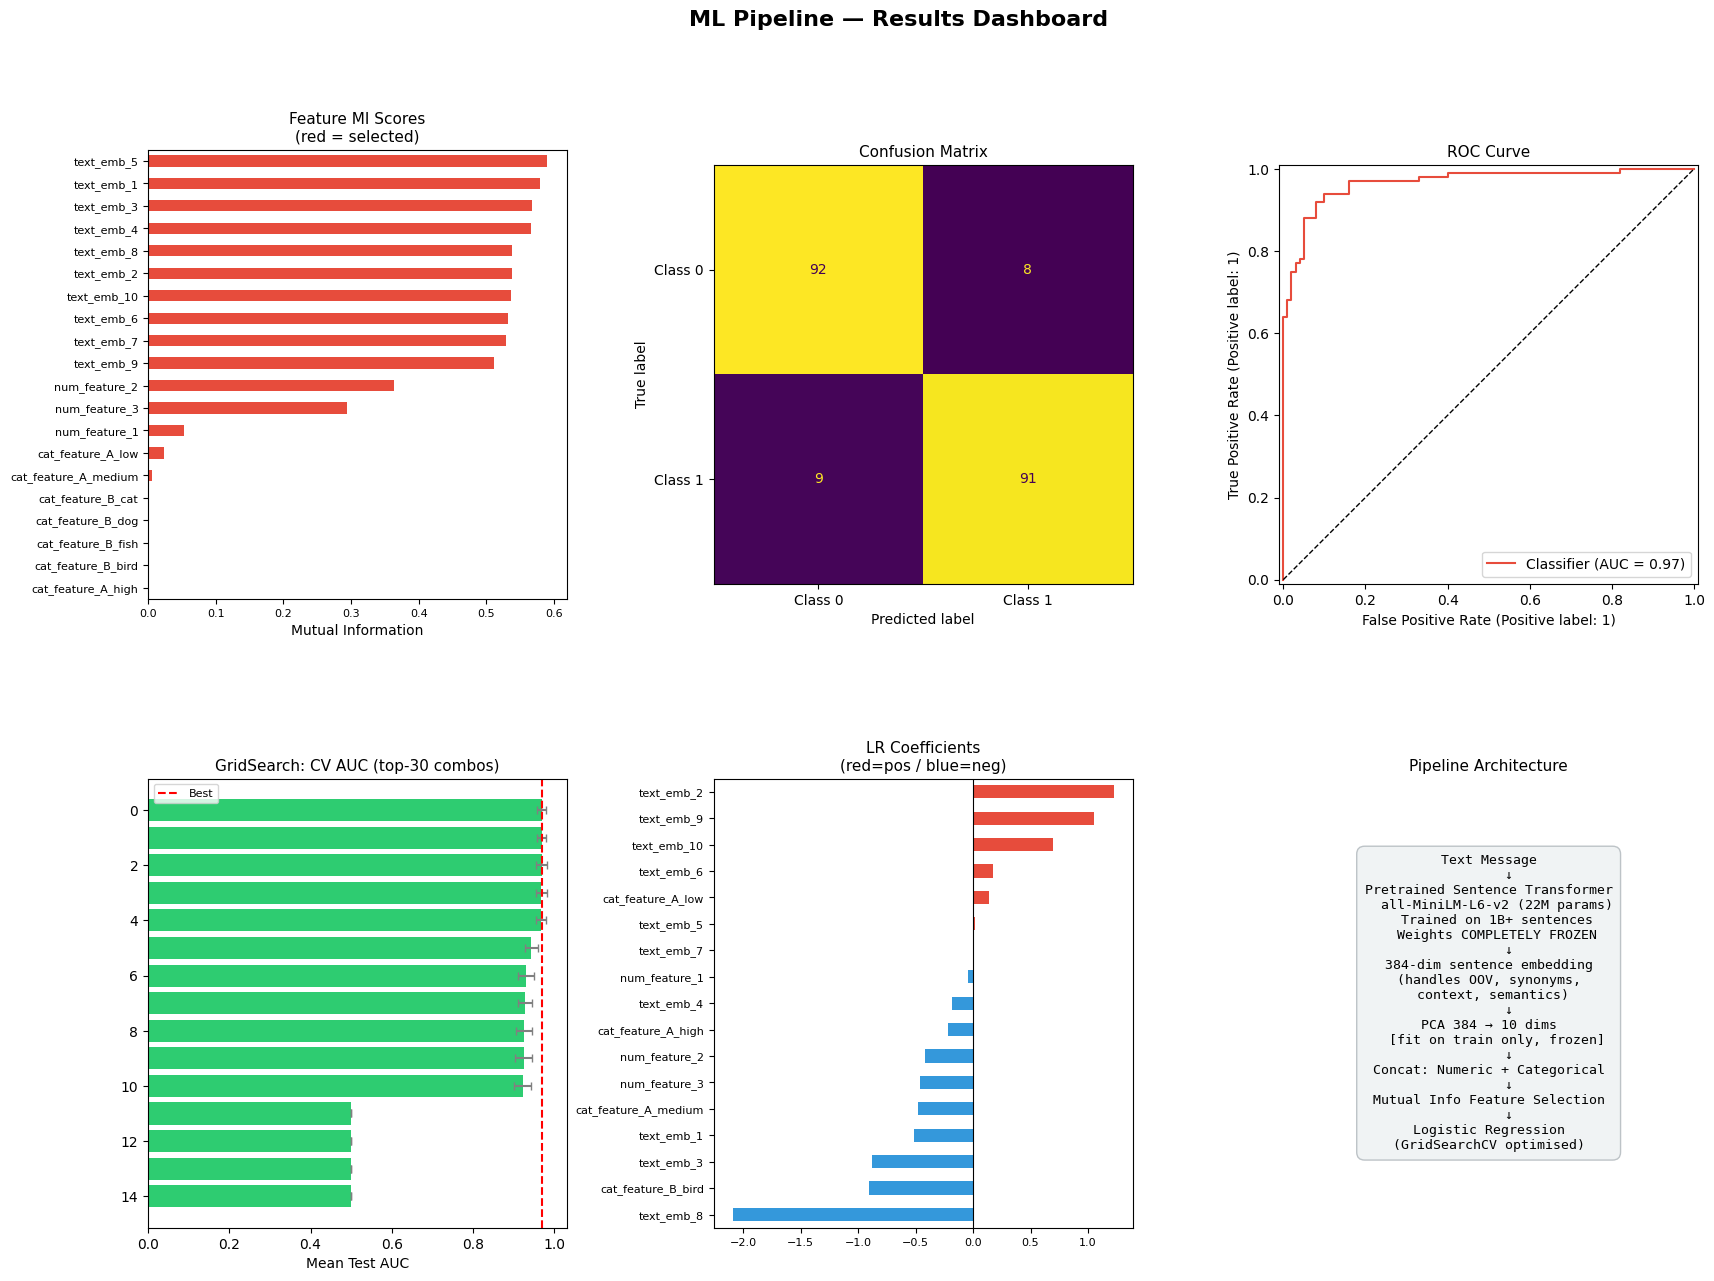


  [Plot] Saved → ml_pipeline_results.png


In [18]:

# =============================================================================
# 8. MAIN
# =============================================================================

print("\n" + "=" * 60)
print("STEP 2 — Build Feature Matrix (Text → 10-dim Embedding)")
print("=" * 60)
embedder = TextEmbedder(out_dim=10)
X_train_full, ohe, scaler = build_feature_matrix(train_df, embedder, fit=True)
X_test_full,  _,   _      = build_feature_matrix(test_df,  embedder, fit=False, ohe=ohe, scaler=scaler)

print(f"\n  Full feature matrix: {X_train_full.shape[1]} features")
print(f"  Columns: {list(X_train_full.columns)}")

print("\n" + "=" * 60)
print(f"STEP 3 — Feature Selection (Mutual Information, top-k)")
num_features = 8
print(f"Number of Features Selected : {num_features}")
print("=" * 60)
k_features = min(num_features, X_train_full.shape[1])
mask, selected_features, mi_scores = select_features(X_train_full, y_train, k=k_features)
X_train_sel = X_train_full.loc[:, mask].values
X_test_sel  = X_test_full.loc[:, mask].values

print("\n" + "=" * 60)
print("STEP 4 — Model Optimisation (GridSearchCV)")
print("=" * 60)
best_model, best_params, cv_results = optimise_model(X_train_sel, y_train.values)

print("\n" + "=" * 60)
print("STEP 5 — Evaluation on Hold-Out Test Set")
print("=" * 60)
y_pred, y_proba, auc = evaluate_model(best_model, X_test_sel, y_test.values, selected_features)

print("\n" + "=" * 60)
print("STEP 6 — Plotting Results")
print("=" * 60)
plot_results(
    best_model, X_test_sel, y_test.values,
    y_pred, y_proba,
    selected_features, mi_scores, cv_results,
)




STEP 3 — Feature Selection (Mutual Information, top-k)
Number of Features Selected : 8

STEP 7 — Compare: WITH vs WITHOUT Text Embeddings

COMPARISON: WITH vs WITHOUT Text Embeddings
  Each variant is built from scratch with its own feature set,
  feature selection, and hyperparameter search.


  ── Variant: WITH text ──
  [TextEmbedder] Loading pretrained model: all-MiniLM-L6-v2 ...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [TextEmbedder] Native embedding dim : 384
  [TextEmbedder] Encoding 800 training sentences ...
  [TextEmbedder] Fitting PCA 384→10 on training embeddings ...
  [TextEmbedder] PCA explained variance : 72.72%
  [TextEmbedder] ✓ PCA FROZEN — same projection applied to test data
    Feature set : 20 features — ['num_feature_1', 'num_feature_2', 'num_feature_3', 'cat_feature_A_high', 'cat_feature_A_low', 'cat_feature_A_medium', 'cat_feature_B_bird', 'cat_feature_B_cat', 'cat_feature_B_dog', 'cat_feature_B_fish', 'text_emb_1', 'text_emb_2', 'text_emb_3', 'text_emb_4', 'text_emb_5', 'text_emb_6', 'text_emb_7', 'text_emb_8', 'text_emb_9', 'text_emb_10']
  [GridSearch] Best params : {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
  [GridSearch] Best CV AUC : 0.9903
    Selected features : ['text_emb_1', 'text_emb_2', 'text_emb_3', 'text_emb_4', 'text_emb_5', 'text_emb_6', 'text_emb_8', 'text_emb_10']
    Best params       : {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
    Hold-out AUC      :

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [TextEmbedder] Native embedding dim : 384
  [TextEmbedder] Encoding 800 training sentences ...
  [TextEmbedder] Fitting PCA 384→10 on training embeddings ...
  [TextEmbedder] PCA explained variance : 72.72%
  [TextEmbedder] ✓ PCA FROZEN — same projection applied to test data
    Feature set : 10 features — ['num_feature_1', 'num_feature_2', 'num_feature_3', 'cat_feature_A_high', 'cat_feature_A_low', 'cat_feature_A_medium', 'cat_feature_B_bird', 'cat_feature_B_cat', 'cat_feature_B_dog', 'cat_feature_B_fish']
  [GridSearch] Best params : {'C': 0.1, 'l1_ratio': 0.3, 'penalty': 'elasticnet', 'solver': 'saga'}
  [GridSearch] Best CV AUC : 0.9301
    Selected features : ['num_feature_1', 'num_feature_2', 'num_feature_3', 'cat_feature_A_medium', 'cat_feature_B_bird', 'cat_feature_B_cat', 'cat_feature_B_dog', 'cat_feature_B_fish']
    Best params       : {'C': 0.1, 'l1_ratio': 0.3, 'penalty': 'elasticnet', 'solver': 'saga'}
    Hold-out AUC      : 0.9056
    Hold-out F1       : 0.8317
    CV

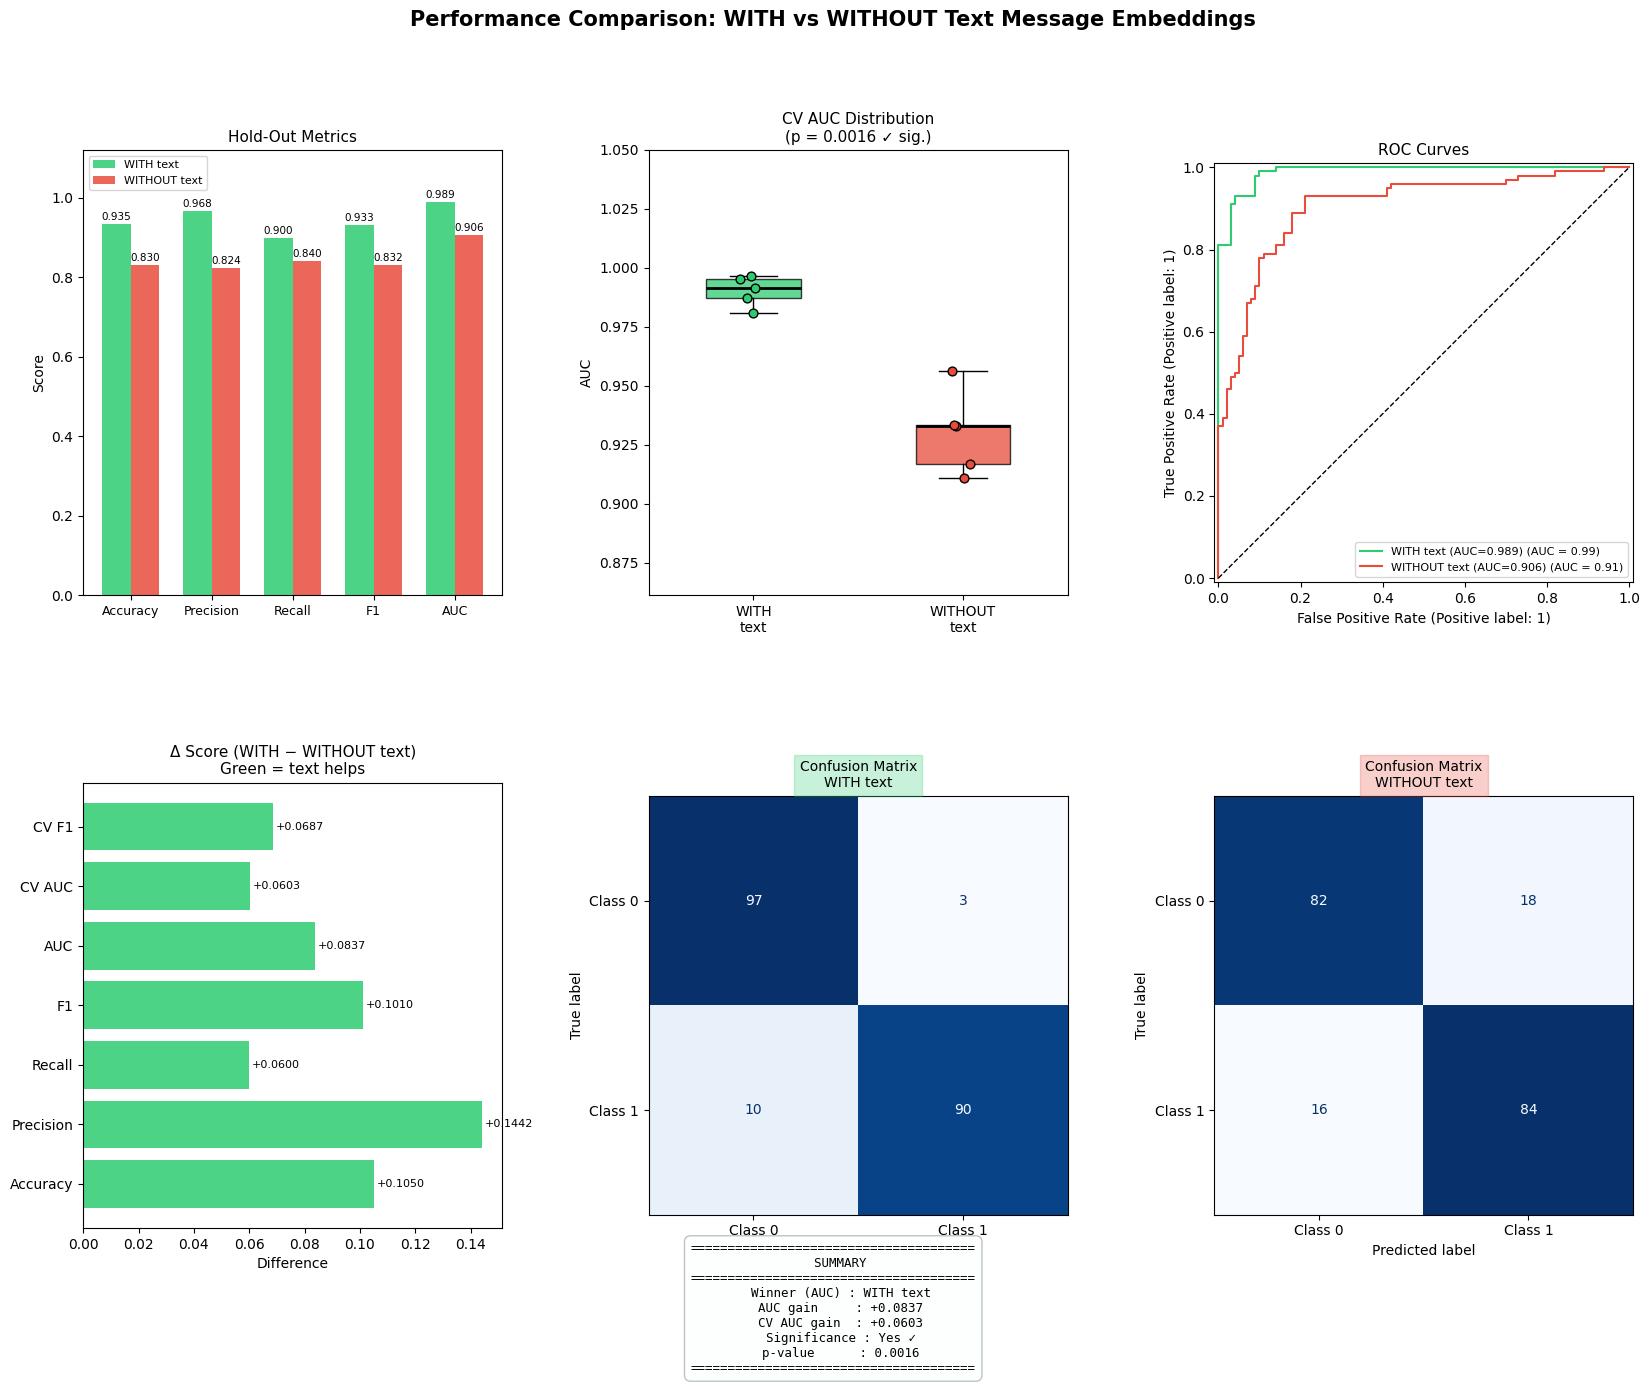


  [Plot] Saved → comparison_results.png


In [19]:

# =============================================================================
# 8. MAIN
# =============================================================================

print("\n" + "=" * 60)
print(f"STEP 3 — Feature Selection (Mutual Information, top-k)")
num_features = 8
print(f"Number of Features Selected : {num_features}")
print("=" * 60)

# ── Step: independent WITH vs WITHOUT text comparison ───────────────
print("\n" + "=" * 60)
print("STEP 7 — Compare: WITH vs WITHOUT Text Embeddings")
print("=" * 60)
with_text, without_text = compare_with_without_text(
    train_df, test_df, y_train, y_test, k_features=num_features
)

